In [5]:
#importacion de librerias

# Pandas: apertura y preprocesamiento del dataset
import pandas as pd

# NumPy: cómputo vectorial y matricial
import numpy as np

# Matplotlib: graficación
from matplotlib import pyplot
%matplotlib inline

# Semilla para reproducibilidad
np.random.seed(42)

In [6]:
#cargar el dataset
df = pd.read_csv('/content/dataset2.csv')

#listar todas las columnas
print('LISTA COMPLETA DE COLUMNAS')
for i, col in enumerate(df.columns):
    print(f'  [{i+1:02d}] {col}')
print()
#primeras 5 filas
df.head()

LISTA COMPLETA DE COLUMNAS
  [01] UID
  [02] BLOCKID
  [03] SUMLEVEL
  [04] COUNTYID
  [05] STATEID
  [06] state
  [07] state_ab
  [08] city
  [09] place
  [10] type
  [11] primary
  [12] zip_code
  [13] area_code
  [14] lat
  [15] lng
  [16] ALand
  [17] AWater
  [18] pop
  [19] male_pop
  [20] female_pop
  [21] rent_mean
  [22] rent_median
  [23] rent_stdev
  [24] rent_sample_weight
  [25] rent_samples
  [26] rent_gt_10
  [27] rent_gt_15
  [28] rent_gt_20
  [29] rent_gt_25
  [30] rent_gt_30
  [31] rent_gt_35
  [32] rent_gt_40
  [33] rent_gt_50
  [34] universe_samples
  [35] used_samples
  [36] hi_mean
  [37] hi_median
  [38] hi_stdev
  [39] hi_sample_weight
  [40] hi_samples
  [41] family_mean
  [42] family_median
  [43] family_stdev
  [44] family_sample_weight
  [45] family_samples
  [46] hc_mortgage_mean
  [47] hc_mortgage_median
  [48] hc_mortgage_stdev
  [49] hc_mortgage_sample_weight
  [50] hc_mortgage_samples
  [51] hc_mean
  [52] hc_median
  [53] hc_stdev
  [54] hc_samples
  [

,UID,BLOCKID,SUMLEVEL,COUNTYID,STATEID,state,state_ab,city,place,type,...,female_age_mean,female_age_median,female_age_stdev,female_age_sample_weight,female_age_samples,pct_own,married,married_snp,separated,divorced
0,267822,NaN,140,53,36,New York,NY,Hamilton,Hamilton,City,...,44.48629,45.33333,22.51276,685.33845,2618.0,0.79046,0.57851,0.01882,0.01240,0.08770
1,246444,NaN,140,141,18,Indiana,IN,South Bend,Roseland,City,...,36.48391,37.58333,23.43353,267.23367,1284.0,0.52483,0.34886,0.01426,0.01426,0.09030
2,245683,NaN,140,63,18,Indiana,IN,Danville,Danville,City,...,42.15810,42.83333,23.94119,707.01963,3238.0,0.85331,0.64745,0.02830,0.01607,0.10657
3,279653,NaN,140,127,72,Puerto Rico,PR,San Juan,Guaynabo,Urban,...,47.77526,50.58333,24.32015,362.20193,1559.0,0.65037,0.47257,0.02021,0.02021,0.10106
4,247218,NaN,140,161,20,Kansas,KS,Manhattan,Manhattan City,City,...,24.17693,21.58333,11.10484,1854.48652,3051.0,0.13046,0.12356,0.00000,0.00000,0.03109


In [7]:
#seleccion de las 20 mejores columas del dataset

# Eliminar columnas no numéricas o identificadoras
drop_cols = ['UID','BLOCKID','SUMLEVEL','COUNTYID','STATEID',
             'state','state_ab','city','place','type','primary',
             'zip_code','area_code']
df_num = df.drop(columns=drop_cols, errors='ignore')

# Variable objetivo
target = 'rent_mean'

# Calcular correlación absoluta de cada columna con rent_mean
correlaciones = df_num.corr()[target].abs().sort_values(ascending=False)

# Seleccionar las 20 de mayor correlación
top20 = correlaciones.drop(target).head(20).index.tolist()

print('20 COLUMNAS SELECCIONADAS PARA X')
for i, col in enumerate(top20):
    print(f'  [{i+1:02d}] {col}  (corr={correlaciones[col]:.4f})')

20 COLUMNAS SELECCIONADAS PARA X
  [01] rent_median  (corr=0.9765)
  [02] hc_mortgage_mean  (corr=0.7576)
  [03] hc_mortgage_median  (corr=0.7566)
  [04] hi_mean  (corr=0.7563)
  [05] hi_median  (corr=0.7534)
  [06] family_mean  (corr=0.7029)
  [07] family_median  (corr=0.7001)
  [08] rent_stdev  (corr=0.6548)
  [09] hi_stdev  (corr=0.6475)
  [10] hc_mean  (corr=0.6009)
  [11] hc_median  (corr=0.5831)
  [12] hc_mortgage_stdev  (corr=0.5708)
  [13] family_stdev  (corr=0.5664)
  [14] debt_cdf  (corr=0.4612)
  [15] hc_stdev  (corr=0.4516)
  [16] debt  (corr=0.4373)
  [17] home_equity_cdf  (corr=0.4303)
  [18] home_equity  (corr=0.4143)
  [19] rent_sample_weight  (corr=0.3894)
  [20] divorced  (corr=0.3792)


In [8]:
#limpieza y preparacion de X e Y


# Conservar solo las columnas necesarias y eliminar filas con valores nulos
cols_use = top20 + [target]
df_clean = df_num[cols_use].dropna().reset_index(drop=True)

# Convertir a arrays NumPy
X = df_clean[top20].values
y = df_clean[target].values
m = y.size

print(f'DATASET LIMPIO')
print(f'  Filas (m)              : {m:,}')
print(f'  Características (n)    : {X.shape[1]}')
print(f'  Variable objetivo      : {target} (renta en USD $)')
print()
print(f'  Y — rent_mean:')
print(f'    Mín   : ${y.min()}')
print(f'    Media : ${y.mean()}')
print(f'    Máx   : ${y.max()}')
print()
print('Primeras 5 filas de X:')
print(X[:5])

DATASET LIMPIO
  Filas (m)              : 26,585
  Características (n)    : 20
  Variable objetivo      : rent_mean (renta en USD $)

  Y — rent_mean:
    Mín   : $172.725
    Media : $1054.36884464322
    Máx   : $3962.34229

Primeras 5 filas de X:
[[7.84000000e+02 1.41480295e+03 1.22300000e+03 6.31252841e+04
  4.81200000e+04 6.79941479e+04 5.32450000e+04 2.32639670e+02
  4.90420121e+04 5.70015300e+02 5.58000000e+02 6.41228980e+02
  4.76673012e+04 7.33410000e-01 2.70112990e+02 5.29630000e-01
  4.90870000e-01 8.91900000e-02 2.72344410e+02 8.77000000e-02]
 [8.48000000e+02 8.64413900e+02 7.84000000e+02 4.19319259e+04
  3.51860000e+04 5.06701034e+04 4.30230000e+04 2.53467470e+02
  3.16395020e+04 3.51982930e+02 3.36000000e+02 4.82270200e+02
  3.47155755e+04 5.81200000e-01 1.25404570e+02 6.08550000e-01
  7.08230000e-01 4.27400000e-02 3.12586220e+02 9.03000000e-02]
 [7.03000000e+02 1.50606758e+03 1.36100000e+03 8.49426832e+04
  7.49640000e+04 9.52625143e+04 8.53950000e+04 3.23390110e+02
  5.

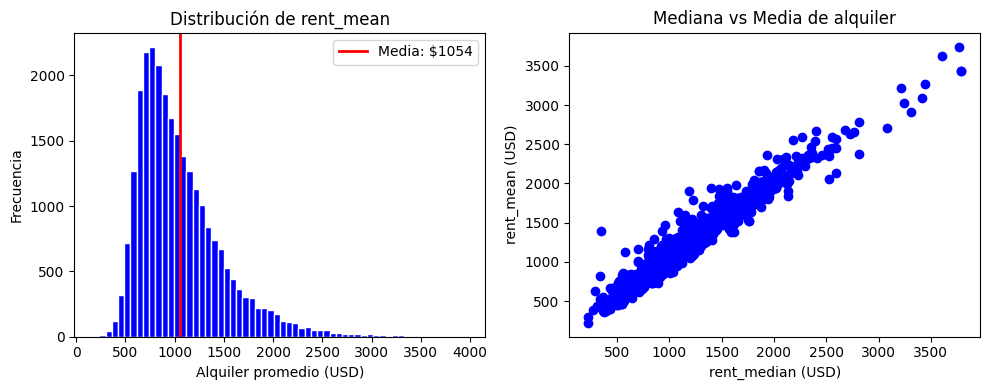

Rango de Y: $172.72 — $3962.34
Media de Y: $1054.37  |  Desv. estándar: $435.32


In [18]:
# =============================================================
# CELDA 6 — Visualización de la distribución de Y
# =============================================================

pyplot.figure(figsize=(10, 4))

# Histograma de rent_mean
pyplot.subplot(1, 2, 1)
pyplot.hist(y, bins=60, color='blue', edgecolor='white')
pyplot.axvline(y.mean(), color='red', lw=2, label=f'Media: ${y.mean():.0f}')
pyplot.xlabel('Alquiler promedio (USD)')
pyplot.ylabel('Frecuencia')
pyplot.title('Distribución de rent_mean')
pyplot.legend()

# Scatter: rent_median vs rent_mean
pyplot.subplot(1, 2, 2)
idx = np.random.choice(m, 2000)
pyplot.scatter(X[idx, 0], y[idx], color='blue')
pyplot.xlabel('rent_median (USD)')
pyplot.ylabel('rent_mean (USD)')
pyplot.title('Mediana vs Media de alquiler')

pyplot.tight_layout()
pyplot.show()

print(f'Rango de Y: ${y.min():.2f} — ${y.max():.2f}')
print(f'Media de Y: ${y.mean():.2f}   Desv. estándar: ${y.std():.2f}')

---
## Funciones comunes: Normalización y Costo

### Normalización Z-score
Las 20 variables tienen escalas muy distintas. Sin normalizar, el gradiente converge lento o diverge. Fórmula:

$$x_{norm} = \frac{x - \mu}{\sigma}$$

### Función de costo (MSE/2)
Mide el error cuadrático medio entre predicciones y valores reales:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

donde la hipótesis es $h_\theta(x) = \theta^T x$.

In [19]:
# normalizacion y costo

#noramlizacion
def normalizarCaracteristicas(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X,  axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

#costo
def calcularCosto(X, y, theta):

    m = len(y)
    h = np.dot(X, theta)
    errores = h - y
    J = (1 / (2*m)) * np.dot(errores, errores)
    return J


#normalización al dataset completo
X_norm, mu, sigma = normalizarCaracteristicas(X)

# Agregar columna de 1s
ones  = np.ones((m, 1))
X_b   = np.concatenate([ones, X_norm], axis=1)

print('Normalización completada.')
print(f'  X_b shape : {X_b.shape}  (m filas, columnas de 1 + 20 características)')
print()
print('Media (mu) de las primeras 5 columnas:')
print('  ', mu[:5])
print('Sigma de las primeras 5 columnas:')
print('  ', sigma[:5])
print()

# Verificación del costo con theta=0 (sin ajuste)
theta0 = np.zeros(X_b.shape[1])
J0 = calcularCosto(X_b, y, theta0)
print(f'Costo inicial con theta = 0: {J0}')

Normalización completada.
  X_b shape : (26585, 21)  (m filas, columnas de 1 + 20 características)

Media (mu) de las primeras 5 columnas:
   [ 1006.73804777  1627.89878663  1549.09023886 70708.34798462
 57780.08527365]
Sigma de las primeras 5 columnas:
   [  441.28681791   620.54738505   649.41688566 29886.13033279
 28842.90765441]

Costo inicial con theta = 0: 650597.86944206


---
## Modelo 1 — Regresión Lineal Multivariable (Descenso por Gradiente)

El descenso por gradiente actualiza θ iterativamente minimizando J(θ):

$$\theta := \theta - \frac{\alpha}{m} X^T (X\theta - y)$$

- **α (alpha)**: tasa de aprendizaje — controla el tamaño del paso en cada iteración.
- Si α es muy grande, el algoritmo puede divergir.
- Si α es muy pequeño, converge lentamente.

In [20]:
# desenso de la gradiente modelo 1

def descensoGradiente(X, y, theta, alpha, num_iters):
    m = len(y)
    J_history = []

    for i in range(num_iters):
        h = np.dot(X, theta)
        errores = h - y
        gradiente = (1/m) * np.dot(X.T, errores)
        theta = theta - alpha * gradiente
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

print('Función descensoGradiente definida')

Función descensoGradiente definida


In [27]:
# entrenamiento del modelo 1 (regresion lineal)

# parámetros de entrenamiento
alpha_lin     = 0.1
num_iters_lin = 3000

# Inicializar theta en ceros: un parámetro por cada característica + sesgo
theta_lin = np.zeros(X_b.shape[1])

print(' ENTRENAMIENTO MODELO 1 — REGRESIÓN LINEAL')
print(f'  Alpha       : {alpha_lin}')
print(f'  Iteraciones : {num_iters_lin}')
print(f'  Costo inicial : {calcularCosto(X_b, y, theta_lin)}')
print()

theta_lin, J_hist_lin = descensoGradiente(X_b, y, theta_lin, alpha_lin, num_iters_lin)

print()
print('RESULTADO MODELO 1')
print(f'  Costo final J : {J_hist_lin[-1]}')
print(f'  Theta (θ₀...θ₅): {theta_lin[:6]}')

 ENTRENAMIENTO MODELO 1 — REGRESIÓN LINEAL
  Alpha       : 0.1
  Iteraciones : 3000
  Costo inicial : 650597.86944206


RESULTADO MODELO 1
  Costo final J : 2736.43996542269
  Theta (θ₀...θ₅): [ 1.05436884e+03  3.60316190e+02  1.51994646e+01 -6.75315388e-01
  6.25573233e+01 -1.87247293e+01]


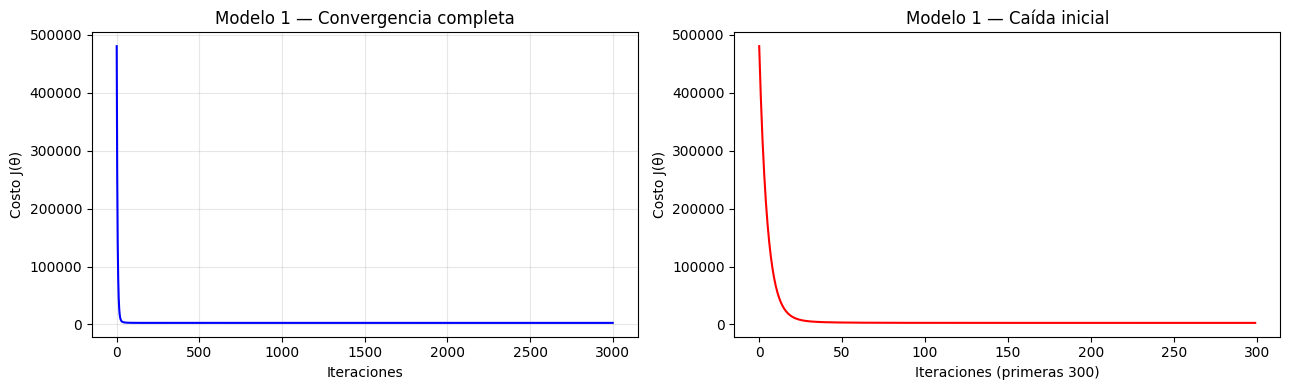

Reducción del costo: 480195.6011473027 → 2736.43996542269
Porcentaje reducido : 99.43014055962098%


In [28]:
#grafica de costo modelo 1

# La curva de costo debe ser monótonamente decreciente si alpha es correcto
fig, axes = pyplot.subplots(1, 2, figsize=(13, 4))

# Convergencia completa
axes[0].plot(np.arange(num_iters_lin), J_hist_lin, color='blue')
axes[0].set_xlabel('Iteraciones')
axes[0].set_ylabel('Costo J(θ)')
axes[0].set_title('Modelo 1 — Convergencia completa')
axes[0].grid(True, alpha=0.3)

# Primeras 300 iteraciones (caída más pronunciada)
axes[1].plot(np.arange(300), J_hist_lin[:300], color='red')
axes[1].set_xlabel('Iteraciones (primeras 300)')
axes[1].set_ylabel('Costo J(θ)')
axes[1].set_title('Modelo 1 — Caída inicial')

pyplot.tight_layout()
pyplot.show()

print(f'Reducción del costo: {J_hist_lin[0]} → {J_hist_lin[-1]}')
print(f'Porcentaje reducido : {(1 - J_hist_lin[-1]/J_hist_lin[0])*100}%')

---
## Modelo 2 — Regresión Polinómica

La regresión polinómica extiende el modelo lineal añadiendo términos elevados al cuadrado de las características originales. Para cada variable $x_j$, se agrega $x_j^2$ como nueva característica:

$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \ldots + \theta_n x_n + \theta_{n+1} x_1^2 + \theta_{n+2} x_2^2 + \ldots$$

Esto permite capturar relaciones **no lineales** entre las variables y el objetivo, sin cambiar el algoritmo de entrenamiento. La normalización es **indispensable** ya que los términos al cuadrado amplifican enormemente las diferencias de escala.

En este caso se usan las **5 variables más correlacionadas** al cuadrado para evitar sobreajuste, resultando en **25 características** (20 originales + 5 cuadráticas).

In [29]:
#construccion de las caracteristicas polinomicas

n_poly = 5   # Número de características a elevar al cuadrado

# Concatenar X original con los términos cuadráticos
X_cuadrado = X[:, :n_poly] ** 2
X_poly = np.concatenate([X, X_cuadrado], axis=1)

# Normalizar el conjunto polinómico completo
X_poly_norm, mu_poly, sigma_poly = normalizarCaracteristicas(X_poly)

# Agregar columna de 1s
X_poly_b = np.concatenate([np.ones((m, 1)), X_poly_norm], axis=1)

print('CARACTERÍSTICAS')
print(f'  Características originales : 20')
print(f'  Términos cuadráticos añadidos: {n_poly}')
print(f'  Total características (+ sesgo): {X_poly_b.shape[1]}')
print()
print('Características cuadráticas añadidas:')
for i in range(n_poly):
    print(f'  x{i+1}² = {top20[i]}²')
print()

J0_poly = calcularCosto(X_poly_b, y, np.zeros(X_poly_b.shape[1]))
print(f'Costo inicial modelo polinómico (theta=0): {J0_poly}')

CARACTERÍSTICAS
  Características originales : 20
  Términos cuadráticos añadidos: 5
  Total características (+ sesgo): 26

Características cuadráticas añadidas:
  x1² = rent_median²
  x2² = hc_mortgage_mean²
  x3² = hc_mortgage_median²
  x4² = hi_mean²
  x5² = hi_median²

Costo inicial modelo polinómico (theta=0): 650597.86944206


In [31]:
#entrenamiento modelo 2 (regresion polinomica)

#parámetros para el modelo polinómico
alpha_poly     = 0.01
num_iters_poly = 3000

# Inicializar theta en ceros para las 26 características (1 sesgo + 25 features)
theta_poly = np.zeros(X_poly_b.shape[1])

print('ENTRENAMIENTO MODELO 2 — REGRESIÓN POLINÓMICA')
print(f'  Alpha       : {alpha_poly}')
print(f'  Iteraciones : {num_iters_poly}')
print(f'  Costo inicial : {calcularCosto(X_poly_b, y, theta_poly)}')
print()

theta_poly, J_hist_poly = descensoGradiente(X_poly_b, y, theta_poly, alpha_poly, num_iters_poly)

print()
print('RESULTADO MODELO 2')
print(f'  Costo final J : {J_hist_poly[-1]}')
print(f'  Theta (θ₀...θ₅): {theta_poly[:6].round(4)}')

ENTRENAMIENTO MODELO 2 — REGRESIÓN POLINÓMICA
  Alpha       : 0.01
  Iteraciones : 3000
  Costo inicial : 650597.86944206


RESULTADO MODELO 2
  Costo final J : 2919.1313429656634
  Theta (θ₀...θ₅): [1054.3688  286.8297   29.1059   25.5072   32.1546   24.9797]


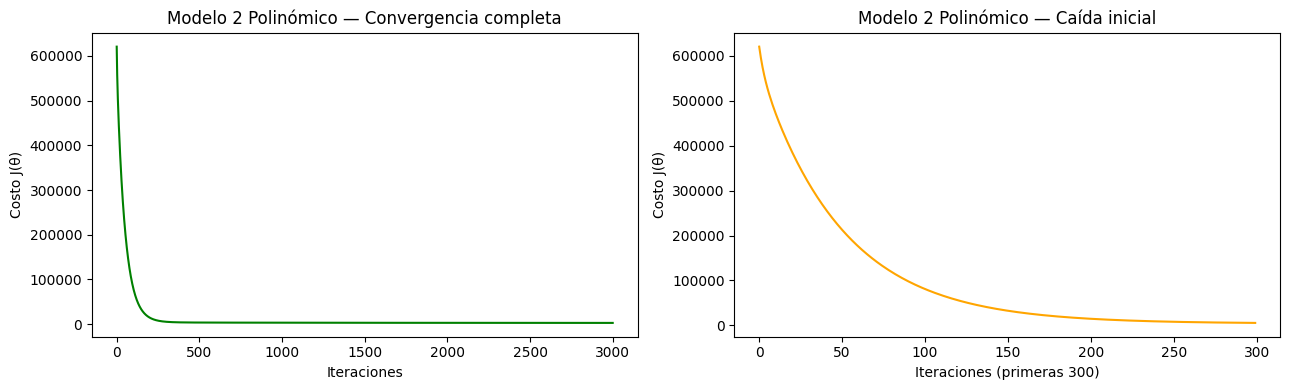

Reducción del costo: 620431.7659 → 2919.1313429656634
Porcentaje reducido : 99.52950001862469%


In [32]:
#grafica de costo modelo 2

# La curva de costo debe ser monótonamente decreciente si alpha es correcto
fig, axes = pyplot.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.arange(num_iters_poly), J_hist_poly, color='green')
axes[0].set_xlabel('Iteraciones')
axes[0].set_ylabel('Costo J(θ)')
axes[0].set_title('Modelo 2 Polinómico — Convergencia completa')

axes[1].plot(np.arange(300), J_hist_poly[:300], color='orange')
axes[1].set_xlabel('Iteraciones (primeras 300)')
axes[1].set_ylabel('Costo J(θ)')
axes[1].set_title('Modelo 2 Polinómico — Caída inicial')

pyplot.tight_layout()
pyplot.show()

print(f'Reducción del costo: {J_hist_poly[0]:.4f} → {J_hist_poly[-1]}')
print(f'Porcentaje reducido : {(1 - J_hist_poly[-1]/J_hist_poly[0])*100}%')

---
## Modelo 3 — Ecuación Normal

Calcula el θ óptimo directamente en un solo paso algebraico, sin iterar:

$$\theta = (X^T X)^{-1} X^T y$$

**Ventajas:**
- No requiere elegir α ni número de iteraciones.
- Resultado exacto en un solo cálculo.

**Desventajas:**
- Computacionalmente costoso si n es muy grande (requiere invertir una matriz n×n).
- No requiere normalización de características.

Para verificar la convergencia de los modelos anteriores, se compara el costo de la ecuación normal con los obtenidos por gradiente.

In [33]:
#ecuacion normal modelo 3

def calcularThetaEcuacionNormal(X, y):
    theta = np.dot(
        np.dot(np.linalg.inv(np.dot(X.T, X)), X.T),
        y
    )
    return theta


# La ecuación normal usa X sin normalizar pero com columna de 1s
X_ne = np.concatenate([np.ones((m, 1)), X], axis=1)

print('CÁLCULO DE THETA — ECUACIÓN NORMAL')
theta_ne = calcularThetaEcuacionNormal(X_ne, y)
J_ne = calcularCosto(X_ne, y, theta_ne)

print(f'  Theta (θ₀...θ₅): {theta_ne[:6].round(4)}')
print()
print(f'  Costo J (Ec. Normal)              : {J_ne}')
print(f'  Costo J (Regresión Lineal Grad.)  : {J_hist_lin[-1]}')
print(f'  Costo J (Regresión Polinómica)    : {J_hist_poly[-1]}')
print()
print('  Si el costo de la Ec. Normal es similar al del gradiente,')
print('  confirma que el descenso convergió correctamente.')

CÁLCULO DE THETA — ECUACIÓN NORMAL
  Theta (θ₀...θ₅): [ 8.01268e+01  8.16000e-01  2.59000e-02 -2.30000e-03  2.70000e-03
 -1.10000e-03]

  Costo J (Ec. Normal)              : 2735.4387075469044
  Costo J (Regresión Lineal Grad.)  : 2736.43996542269
  Costo J (Regresión Polinómica)    : 2919.1313429656634

  Si el costo de la Ec. Normal es similar al del gradiente,
  confirma que el descenso convergió correctamente.


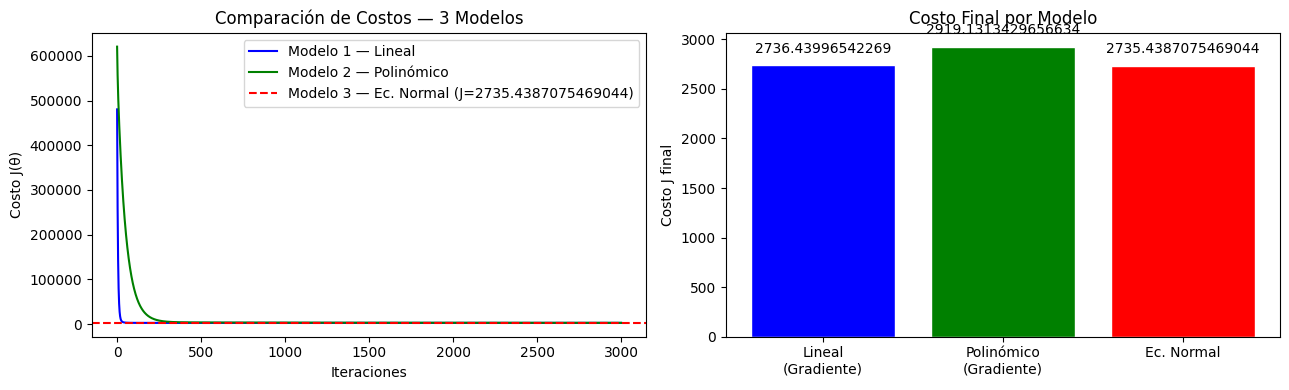

=== RESUMEN DE COSTOS FINALES ===
  Lineal (Gradiente)            : 2736.43996542269
  Polinómico (Gradiente)        : 2919.1313429656634
  Ec. Normal                    : 2735.4387075469044


In [35]:
#grafica comparativa de costos de los 3 modelos

# Comparar la curva de convergencia de los dos modelos iterativos
# y el costo fijo de la ecuación normal (línea horizontal)

fig, axes = pyplot.subplots(1, 2, figsize=(13, 4))

#Gráfica 1: Comparación de convergencia
axes[0].plot(np.arange(num_iters_lin),  J_hist_lin, color='blue',  label='Modelo 1 — Lineal')
axes[0].plot(np.arange(num_iters_poly), J_hist_poly, color='green',   label='Modelo 2 — Polinómico')
axes[0].axhline(J_ne, color='red', lw=1.5, linestyle='--', label=f'Modelo 3 — Ec. Normal (J={J_ne})')
axes[0].set_xlabel('Iteraciones')
axes[0].set_ylabel('Costo J(θ)')
axes[0].set_title('Comparación de Costos — 3 Modelos')
axes[0].legend()

#Gráfica 2: Costo final de cada modelo (barras)
modelos = ['Lineal\n(Gradiente)', 'Polinómico\n(Gradiente)', 'Ec. Normal']
costos  = [J_hist_lin[-1], J_hist_poly[-1], J_ne]
colores = ['blue', 'green', 'red']
bars = axes[1].bar(modelos, costos, color=colores, edgecolor='white')
for bar, costo in zip(bars, costos):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{costo}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Costo J final')
axes[1].set_title('Costo Final por Modelo')
pyplot.tight_layout()
pyplot.show()

print('=== RESUMEN DE COSTOS FINALES ===')
for nombre, costo in zip(modelos, costos):
    print(f'  {nombre.replace(chr(10)," "):<30}: {costo}')

---
## Validación — 100 Predicciones

Se toman 100 ejemplos aleatorios del dataset para evaluar los tres modelos.
Se calcula el **RMSE** (Root Mean Squared Error) para cuantificar la precisión:

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2}$$

Un RMSE más bajo indica predicciones más precisas.

In [36]:
#100 predicciones para la validacion con lso 3 modelos

# Seleccionar 100 índices aleatorios del dataset
n_pred = 100
indices = np.random.choice(m, size=n_pred, replace=False)

# Almacenar predicciones de cada modelo
preds_lin  = []
preds_poly = []
preds_ne   = []
y_reales   = []

for idx in indices:
    # Valor real
    y_real = y[idx]
    y_reales.append(y_real)

    #Modelo 1: Lineal (usar normalización del entrenamiento)
    x_n = (X[idx] - mu) / sigma
    x1  = np.concatenate([[1], x_n])
    preds_lin.append(np.dot(x1, theta_lin))

    #Modelo 2: Polinómico
    x_poly = np.concatenate([X[idx], X[idx, :n_poly]**2])   # 25 características
    x_pn   = (x_poly - mu_poly) / sigma_poly
    x2     = np.concatenate([[1], x_pn])
    preds_poly.append(np.dot(x2, theta_poly))

    #Modelo 3: Ecuación Normal
    x3 = np.concatenate([[1], X[idx]])
    preds_ne.append(np.dot(x3, theta_ne))

preds_lin  = np.array(preds_lin)
preds_poly = np.array(preds_poly)
preds_ne   = np.array(preds_ne)
y_reales   = np.array(y_reales)

# Calcular RMSE
rmse_lin  = np.sqrt(np.mean((preds_lin  - y_reales)**2))
rmse_poly = np.sqrt(np.mean((preds_poly - y_reales)**2))
rmse_ne   = np.sqrt(np.mean((preds_ne   - y_reales)**2))

print(f'RMSE EN 100 PREDICCIONES')
print(f'  Modelo 1 — Lineal (Gradiente) : ${rmse_lin} USD')
print(f'  Modelo 2 — Polinómico         : ${rmse_poly} USD')
print(f'  Modelo 3 — Ecuación Normal    : ${rmse_ne} USD')
print()
print(f'  Media de rent_mean en muestra : ${y_reales.mean()} USD')
print()

# Tabla de primeras 10 predicciones
print(f"{'Idx':>6}  {'Real':>10}  {'M1-Lineal':>12}  {'M2-Polinóm':>12}  {'M3-EcNorm':>12}")

for i in range(10):
    print(f"{indices[i]:>6}  ${y_reales[i]:>9.2f}  ${preds_lin[i]:>11.2f}  ${preds_poly[i]:>11.2f}  ${preds_ne[i]:>11.2f}")
print(f'  (100 predicciones totales calculadas)')

RMSE EN 100 PREDICCIONES
  Modelo 1 — Lineal (Gradiente) : $57.6303502409746 USD
  Modelo 2 — Polinómico         : $58.719766754257414 USD
  Modelo 3 — Ecuación Normal    : $57.61643449340899 USD

  Media de rent_mean en muestra : $1091.3793812 USD

   Idx        Real     M1-Lineal    M2-Polinóm     M3-EcNorm
  8888  $   899.76  $     918.54  $     920.32  $     916.13
 23811  $  1157.55  $    1114.28  $    1116.92  $    1114.58
 20881  $  2518.98  $    2447.64  $    2480.88  $    2447.81
 14096  $  1475.99  $    1444.02  $    1429.30  $    1443.84
 15027  $   817.11  $     824.30  $     797.37  $     823.21
 22661  $   585.15  $     673.52  $     694.61  $     672.32
 15248  $  1607.29  $    1639.22  $    1627.18  $    1636.80
 24720  $   692.60  $     707.67  $     698.83  $     708.82
 15388  $   915.90  $     904.62  $     885.24  $     905.36
 19211  $   719.93  $     793.97  $     794.72  $     793.77
  (100 predicciones totales calculadas)


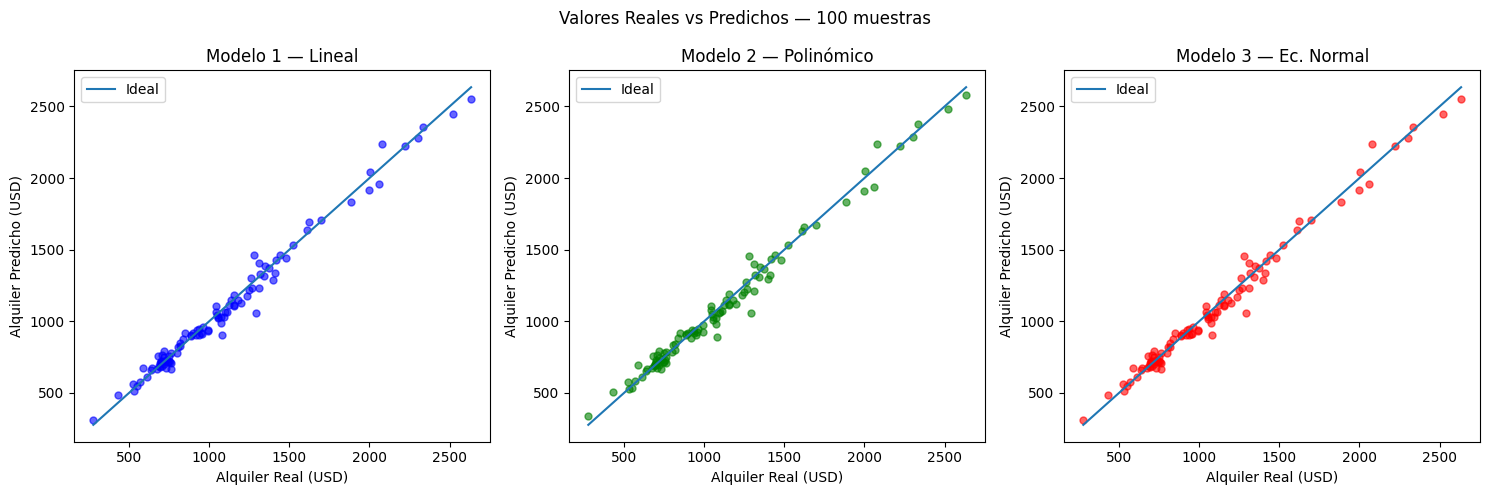

Puntos más cercanos a la línea diagonal = mejor predicción.


In [40]:
#grafica de comparacion de valores reales vs los valores predichos

fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))

for ax, preds, nombre, color in zip(
    axes,
    [preds_lin, preds_poly, preds_ne],
    ['Modelo 1 — Lineal', 'Modelo 2 — Polinómico', 'Modelo 3 — Ec. Normal'],
    ['blue', 'green', 'red']
):
    ax.scatter(y_reales, preds, alpha=0.6, s=25, color=color)
    # Línea diagonal ideal
    lim_min = min(y_reales.min(), preds.min())
    lim_max = max(y_reales.max(), preds.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], label='Ideal')
    ax.set_xlabel('Alquiler Real (USD)')
    ax.set_ylabel('Alquiler Predicho (USD)')
    ax.set_title(nombre)
    ax.legend()

pyplot.suptitle('Valores Reales vs Predichos — 100 muestras')
pyplot.tight_layout()
pyplot.show()

print('Puntos más cercanos a la línea diagonal = mejor predicción.')

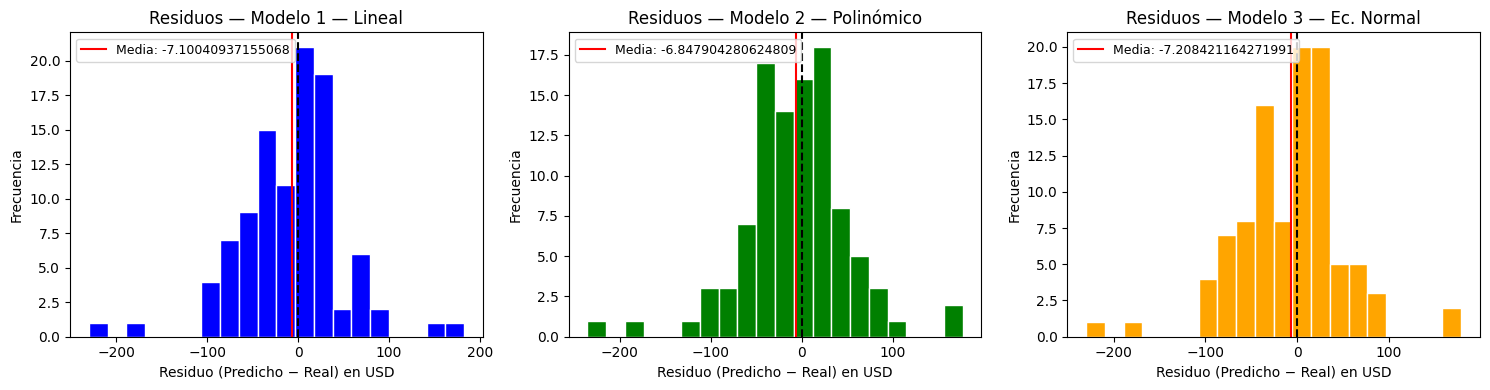

Un histograma simétrico centrado en 0 indica predicciones sin sesgo sistemático.


In [43]:
#grafica de errores


fig, axes = pyplot.subplots(1, 3, figsize=(15, 4))

for ax, preds, nombre, color in zip(
    axes,
    [preds_lin, preds_poly, preds_ne],
    ['Modelo 1 — Lineal', 'Modelo 2 — Polinómico', 'Modelo 3 — Ec. Normal'],
    ['blue', 'green', 'orange']
):
    residuos = preds - y_reales
    ax.hist(residuos, bins=20, color=color, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--')
    ax.axvline(residuos.mean(), color='red', label=f'Media: {residuos.mean()}')
    ax.set_xlabel('Residuo (Predicho − Real) en USD')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Residuos — {nombre}')
    ax.legend(fontsize=9)

pyplot.tight_layout()
pyplot.show()

print('Un histograma simétrico centrado en 0 indica predicciones sin sesgo sistemático.')